**Pengumpulan dan persiapan data**
Data yang digunakan dalam membuat model dengan K-Means Clustering yakni data yang diambil dari GPS Trajectories, dataset dari UCI Machine Learning Repository yang berisi data perjalanan (trajectory) yang dikumpulkan dari aplikasi Android Go!Track. Dataset dapat diakses pada tautan berikut: https://archive.ics.uci.edu/dataset/354/gps+trajectories . Dataset ini biasanya digunakan untuk:
- klasifikasi moda transportasi
- analisis mobilitas pengguna
- clustering perjalanan
- prediksi aktivitas/pergerakan
Untuk dapat melihat dataset tersebut anda dapat mencoba dengan menggunakan langkah-langkah berikut ini:


Buatlah satu buah project baru dan lakukan load library berikut ini:

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score

Kemudian lakukan load data sehingga data tersebut diubah formatnya ke dalam data frame seperti berikut ini.

In [14]:
baca = pd.read_csv("/content/go_track_tracks.csv")
baca.head()


,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus,linha
0,1,0,19.210586,0.138049,2.652,3,0,0,1,NaN
1,2,0,30.848229,0.171485,5.290,3,0,0,1,NaN
2,3,1,13.560101,0.067699,0.918,3,0,0,2,NaN
3,4,1,19.766679,0.389544,7.700,3,0,0,2,NaN
4,8,0,25.807401,0.154801,3.995,2,0,0,1,NaN


Selanjutnya untuk melihat informasi tentang dataset dapat menggunakan kode berikut.

In [15]:
baca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              163 non-null    int64  
 1   id_android      163 non-null    int64  
 2   speed           163 non-null    float64
 3   time            163 non-null    float64
 4   distance        163 non-null    float64
 5   rating          163 non-null    int64  
 6   rating_bus      163 non-null    int64  
 7   rating_weather  163 non-null    int64  
 8   car_or_bus      163 non-null    int64  
 9   linha           80 non-null     object 
dtypes: float64(3), int64(6), object(1)
memory usage: 12.9+ KB


Untuk selanjutnya, kolom dapat kita kurangi dengan menggunakan kode berikut. Kolom ini kita kurangi karena tidak dipergunakan dalam penentuan pada clustering.

In [16]:
baca = baca.drop(["linha"], axis=1)
baca.head()

,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus
0,1,0,19.210586,0.138049,2.652,3,0,0,1
1,2,0,30.848229,0.171485,5.290,3,0,0,1
2,3,1,13.560101,0.067699,0.918,3,0,0,2
3,4,1,19.766679,0.389544,7.700,3,0,0,2
4,8,0,25.807401,0.154801,3.995,2,0,0,1


Kemudian, kita akan menentukan variabel yang akan diklusterkan. Setelah penentuan variabel, maka kita dapat melakukan plot data dari data tersebut untuk melihat sebaran data.

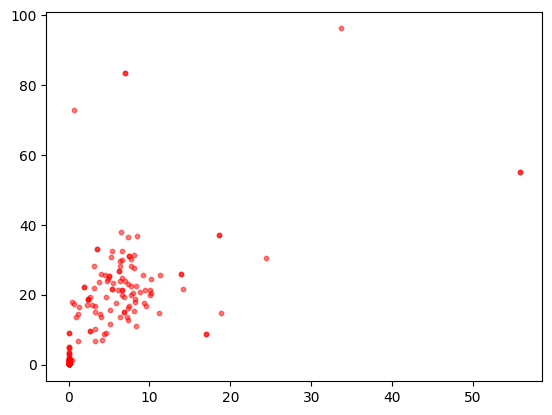

In [17]:
#Menentukan variabel yang akan di klusterkan
baca_x = baca.iloc[:, 1:3]
baca_x.head()
#Memvisualkan persebaran data
plt.scatter(baca.distance, baca.speed, s =10, c = "red", marker = "o", alpha = 0.5)
plt.show()


Untuk menentukan nilai kluster yang kita inginkan kita harus mengubah variabel data yang berbentuk frame terlebih dahulu untuk menjadi array

In [18]:
x_array = np.array(baca_x)
print(x_array)

[[0.00000000e+00 1.92105856e+01]
 [0.00000000e+00 3.08482291e+01]
 [1.00000000e+00 1.35601009e+01]
 [1.00000000e+00 1.97666790e+01]
 [0.00000000e+00 2.58074009e+01]
 [2.00000000e+00 1.34691332e+00]
 [3.00000000e+00 3.68507874e+01]
 [1.00000000e+00 1.74051313e+01]
 [1.00000000e+00 1.53954361e+01]
 [1.00000000e+00 8.90272944e+00]
 [3.00000000e+00 1.50413480e+01]
 [3.00000000e+00 1.44400981e+01]
 [1.00000000e+00 1.63567325e+01]
 [1.00000000e+00 1.75427999e+01]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 1.62635039e+01]
 [4.00000000e+00 2.12235944e+01]
 [4.00000000e+00 1.94236545e+01]
 [4.00000000e+00 2.07996291e+01]
 [4.00000000e+00 8.72437242e+00]
 [4.00000000e+00 8.72437242e+00]
 [3.00000000e+00 8.68613764e+00]
 [3.00000000e+00 5.49959473e+01]
 [3.00000000e+00 5.49959473e+01]
 [1.00000000e+00 1.26110448e+01]
 [3.00000000e+00 1.45342872e+01]
 [3.00000000e+00 1.02882267e+01]
 [3.00000000e+00 1.83281891e+01]
 [1.00000000e+00 1.71776350e+01]
 [1.000000

Selanjutnya pada kode berikutnya, kita akan melakukan normalisasi data menggunakan metode Min-Max Scaling seperti kode dibawah ini

In [19]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)
x_scaled

array([[0.00000000e+00, 1.99600362e-01],
       [0.00000000e+00, 3.20578504e-01],
       [3.70370370e-02, 1.40861225e-01],
       [3.70370370e-02, 2.05381184e-01],
       [0.00000000e+00, 2.68176999e-01],
       [7.40740741e-02, 1.39000630e-02],
       [1.11111111e-01, 3.82977592e-01],
       [3.70370370e-02, 1.80831914e-01],
       [3.70370370e-02, 1.59940297e-01],
       [3.70370370e-02, 9.24459124e-02],
       [1.11111111e-01, 1.56259404e-01],
       [1.11111111e-01, 1.50009162e-01],
       [3.70370370e-02, 1.69933373e-01],
       [3.70370370e-02, 1.82263037e-01],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 1.68964223e-01],
       [1.48148148e-01, 2.20526426e-01],
       [1.48148148e-01, 2.01815302e-01],
       [1.48148148e-01, 2.16119130e-01],
       [1.48148148e-01, 9.05918170e-02],
       [1.48148148e-01, 9.05918170e-02],
       [1.11111111e-01, 9.01943506e-02],
       [1.11111111e-01, 5.71604072e-01],
       [1.111111

# **Membuat Model Klasifikasi**
Anda dapat melakukan pembuatan model klasifikasi dengan melakukan hal berikut:

In [20]:
from sklearn.cluster import KMeans

# Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Training model
kmeans.fit(baca)

# Menampilkan label cluster
print(kmeans.labels_)

# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_

# Menampilkan data
print(baca.head())


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
   id  id_android      speed      time  distance  rating  rating_bus  \
0   1           0  19.210586  0.138049     2.652       3           0   
1   2           0  30.848229  0.171485     5.290       3           0   
2   3           1  13.560101  0.067699     0.918       3           0   
3   4           1  19.766679  0.389544     7.700       3           0   
4   8           0  25.807401  0.154801     3.995       2           0   

   rating_weather  car_or_bus  kluster  
0               0           1        0  
1               0           1        0  
2               0           2        0  
3               0           2        0  
4               0           1 

### Visualisasi Hasil K-Means Clustering

Sekarang, mari kita visualisasikan hasil pengelompokan K-Means. Kita akan membuat plot sebar (scatter plot) menggunakan kolom `distance` dan `speed`, dan mewarnai setiap titik data berdasarkan `kluster` yang telah ditetapkan oleh model K-Means.

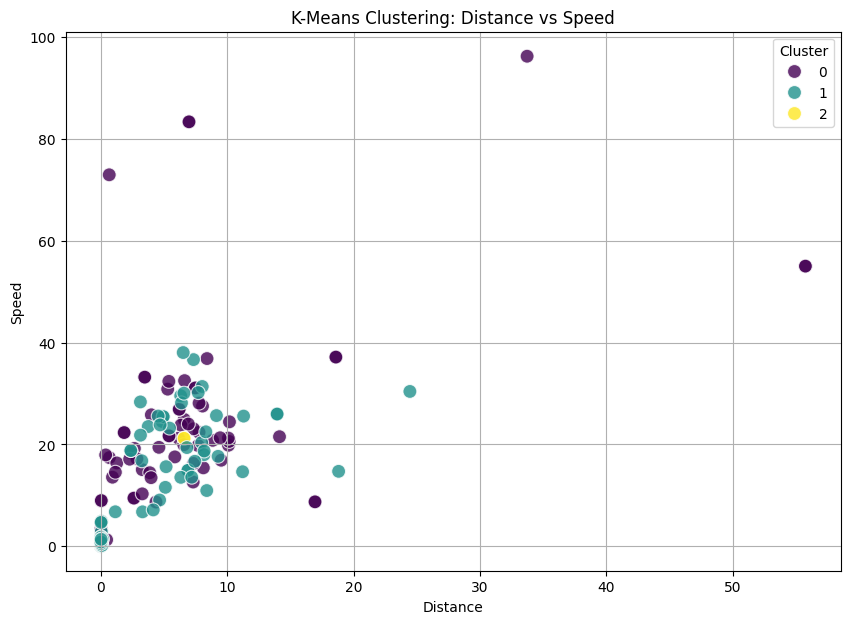

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='distance', y='speed', hue='kluster', data=baca, palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clustering: Distance vs Speed')
plt.xlabel('Distance')
plt.ylabel('Speed')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

### Evaluasi K-Means Clustering dengan Metrik Tanpa Pengawasan
Karena K-Means adalah algoritma pembelajaran tanpa pengawasan, metrik seperti akurasi, presisi, dan F1-score tidak berlaku secara langsung. Sebagai gantinya, kita dapat menggunakan metrik evaluasi klaster internal seperti Silhouette Score dan Davies-Bouldin Score untuk menilai kualitas klaster.

*   **Silhouette Score**: Mengukur seberapa mirip suatu objek dengan clusternya sendiri dibandingkan dengan cluster tetangga. Nilai yang lebih tinggi menunjukkan klaster yang lebih baik.
*   **Davies-Bouldin Score**: Mengukur rasio antara penyebaran di dalam klaster dan pemisahan antar klaster. Nilai yang lebih rendah menunjukkan klaster yang lebih baik.

In [25]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Memastikan kita menggunakan data yang sudah diskalakan dan label klaster
# Ambil kolom 'distance' dan 'speed' dari DataFrame 'baca' setelah drop 'linha'
# Dan pastikan kita menggunakan 'baca_x' yang sudah di-scale menjadi 'x_scaled'

# Perhitungan Silhouette Score
silhouette_avg = silhouette_score(x_scaled, baca['kluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Perhitungan Davies-Bouldin Score
davies_bouldin_avg = davies_bouldin_score(x_scaled, baca['kluster'])
print(f"Davies-Bouldin Score: {davies_bouldin_avg:.3f}")

Silhouette Score: -0.098
Davies-Bouldin Score: 2.022


Visualisasi dari kluster dapat dilakukan untuk memperlihatkan sebaran data hasil dari model cluster yang dilakukan seperti berikut (termasuk dengan plot data centroid)

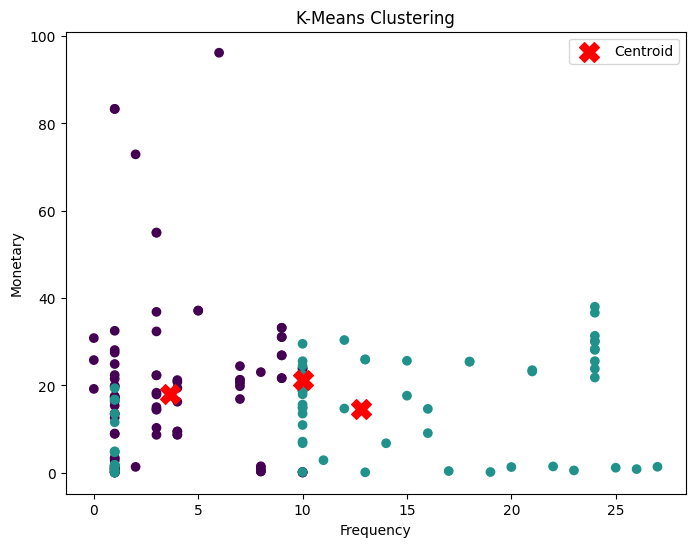

In [26]:
import matplotlib.pyplot as plt

# Plot hasil clustering
plt.figure(figsize=(8,6))

plt.scatter(
    baca['id_android'],
    baca['speed'],
    c=baca['kluster'],
    cmap='viridis'
)

# Titik centroid
plt.scatter(
    kmeans.cluster_centers_[:, 1],   # Frequency
    kmeans.cluster_centers_[:, 2],   # Monetary
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('K-Means Clustering')
plt.legend()

plt.show()